In [1]:
# 第1章｜上市櫃資料 API 操作：每次開啟 notebook，先執行這一格（安裝套件、登入 FinLab、開啟資料快取）
%pip install -q finlab==2.0.21 ta-lib==0.8.1
import finlab
from finlab import data

finlab.login()
data.set_storage(data.FileStorage())

Note: you may need to restart the kernel to use updated packages.


已登入（使用快取憑證）。


# 上市櫃資料 API 操作

**對應影片**：第 1 章 單元 4、5「獨家上市櫃資料存儲 API 操作 Part 1、Part 2」

**和影片的差異**

| 影片（2018） | 新版教材 |
| --- | --- |
| `from finlab.data import Data`、`data = Data()`、`data.get('收盤價')` 讀本機 pickle | `from finlab import data`、`data.get('price:收盤價')`，名稱寫成「資料表:欄位」 |
| `data.get_adj('收盤價')` 還原股價 | `data.get('etl:adj_close')` |
| 季報、月報要自己對齊日期 | `FinlabDataFrame` 會自動對齊不同頻率的資料 |

Part 1 學會「拿資料」，Part 2 學會「組合資料」並做出第一個選股條件。

## Part 1：拿資料

### 1-1 找資料名稱

不知道資料叫什麼名字時，用 `data.search` 搜尋關鍵字。完整清單可以到 [FinLab 資料庫目錄](https://www.finlab.finance/data) 查。

In [2]:
data.search('營收')

0             monthly_revenue:當月營收
1             monthly_revenue:上月營收
2           monthly_revenue:去年當月營收
3           monthly_revenue:當月累計營收
4           monthly_revenue:去年累計營收
5     fundamental_features:業外收支營收率
6       fundamental_features:營收成長率
7        rotc_monthly_revenue:當月營收
8        rotc_monthly_revenue:上月營收
9      rotc_monthly_revenue:去年當月營收
10     rotc_monthly_revenue:當月累計營收
11     rotc_monthly_revenue:去年累計營收
Name: dataset, dtype: object

### 1-2 日資料：股價

回傳的是 `FinlabDataFrame`：**列是日期、欄是股票代號**，用法和 pandas DataFrame 一樣。

In [3]:
close = data.get('price:收盤價')
volume = data.get('price:成交股數')

close[['0050', '2330', '2317', '2454']].tail()

symbol,0050,2330,2317,2454
date,,,,
2018-12-24,74.70,220.0,71.4,225.0
2018-12-25,73.75,217.5,70.7,221.0
2018-12-26,73.55,216.5,70.2,220.0
2018-12-27,75.05,223.0,70.8,225.0
2018-12-28,75.50,225.5,70.8,229.5


常見的取法：

In [4]:
tsmc = close['2330']                      # 單一股票 → Series
recent = close.loc['2018-01':'2018-06']   # 一段期間
latest = close.iloc[-1].dropna()          # 最後一天所有股票

print('台積電最後 3 天收盤價：', tsmc.tail(3).tolist())
print('2018 上半年交易日數：', len(recent))
print('最後一天有收盤價的股票數：', len(latest))

台積電最後 3 天收盤價： [216.5, 223.0, 225.5]
2018 上半年交易日數： 118
最後一天有收盤價的股票數： 1832


### 1-3 還原股價

除權息那天股價會「跳下去」，但投資人並沒有虧錢。計算報酬率要用還原股價，否則會低估配息股的報酬。

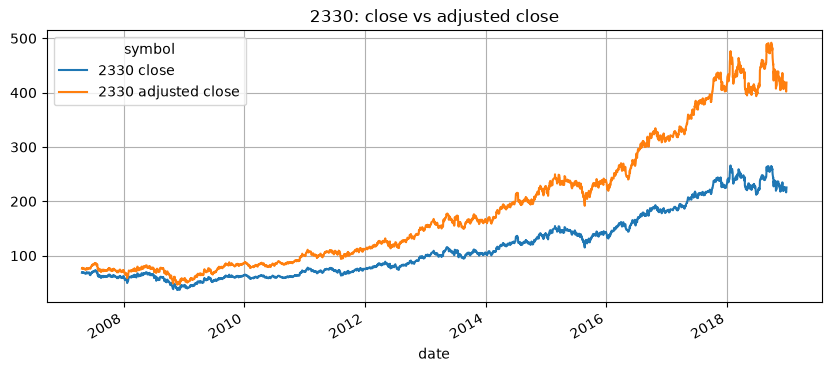

In [5]:
adj_close = data.get('etl:adj_close')

compare = close[['2330']].join(adj_close[['2330']], lsuffix=' close', rsuffix=' adjusted close')
compare.plot(figsize=(10, 4), title='2330: close vs adjusted close', grid=True);

### 1-4 股票名稱與產業

In [6]:
categories = data.get('security_categories').set_index('stock_id')
categories.loc[['0050', '2330', '2317', '2454'], ['name', 'category', 'market']]

,name,category,market
stock_id,,,
0050,元大台灣50,domestic_etf,etf
2330,台積電,半導體業,sii
2317,鴻海,其他電子業,sii
2454,聯發科,半導體業,sii


### 1-5 月營收與季報

月營收的 index 是**公布截止日**（每月 10 日左右，遇假日順延），季報的 index 是**季度**（例如 `2018-Q3`）。
資料的日期代表「那一天就拿得到」，所以可以直接拿來和股價一起算。

In [7]:
revenue = data.get('monthly_revenue:當月營收')
revenue['2330'].tail()

date
2018-08-10     74370924.0
2018-09-10     91055038.0
2018-10-11     94921920.0
2018-11-12    101550181.0
2018-12-10     98389414.0
Name: 2330, dtype: float64

In [8]:
roe = data.get('fundamental_features:ROE稅後')
roe['2330'].tail()

date
2017-Q3    6.485683
2017-Q4    6.723105
2018-Q1    5.738390
2018-Q2    4.668244
2018-Q3    5.811125
Name: 2330, dtype: float64

自己從財報算一次 ROE 驗證：ROE（稅後）= 歸屬母公司淨利 ÷ 平均母公司股東權益（本季與上季平均）× 100。

In [9]:
net_income = data.get('financial_statement:歸屬母公司淨利_損')
equity = data.get('financial_statement:母公司股東權益合計')

my_roe = net_income / equity.rolling(2).mean() * 100
my_roe['2330'].tail()

date
2017-Q3    6.487185
2017-Q4    6.724938
2018-Q1    5.740786
2018-Q2    4.670082
2018-Q3    5.811849
Name: 2330, dtype: float64

## Part 2：組合資料

### 2-1 季報轉成每日資料

季報一季只有一筆，要和每日股價一起用，就把它轉成「每天看得到的最新一季數值」：
先用 `index_str_to_date()` 把 `2018-Q3` 轉成實際公布的日期，再用 `reindex(..., method='ffill')` 延續到每個交易日。

In [10]:
daily_roe = roe.index_str_to_date().reindex(close.index, method='ffill')
daily_roe['2330'].tail()

date
2018-12-24    5.811125
2018-12-25    5.811125
2018-12-26    5.811125
2018-12-27    5.811125
2018-12-28    5.811125
Name: 2330, dtype: float64

### 2-2 讓 FinlabDataFrame 自動對齊

不同頻率的 `FinlabDataFrame` 直接運算時，會自動對齊日期與股票，不用手動轉換。
下面把「日頻的股價」和「月頻的營收」放在同一個條件裡：

In [11]:
price_above_ma60 = close > close.average(60)
revenue_growing = revenue.average(3) > revenue.average(12)

condition = price_above_ma60 & revenue_growing
print('每天符合條件的股票數：')
condition.sum(axis=1).tail()

每天符合條件的股票數：


date
2018-12-24    517
2018-12-25    467
2018-12-26    447
2018-12-27    511
2018-12-28    539
dtype: int64

`close.average(60)` 是 60 日均線，和 `close.rolling(60).mean()` 一樣。其他常用的 FinlabDataFrame 函式：

| 函式 | 意思 |
| --- | --- |
| `df.average(n)` | n 期移動平均 |
| `df.rise(n)` / `df.fall(n)` | 和 n 期前相比上漲 / 下跌 |
| `df.sustain(n)` | 條件連續成立 n 期 |
| `df.is_largest(n)` / `df.is_smallest(n)` | 每天數值最大 / 最小的 n 檔 |

### 2-3 第一個選股：營收成長、股價強勢、流動性足夠

1. 股價在 60 日均線之上。
2. 近 3 個月平均營收大於近 12 個月平均營收。
3. 近 20 日平均成交量大於 `MIN_VOLUME_SHARES` 股，避免買到很難成交的股票。
4. 符合條件的股票中，挑營收成長最多的 `N_STOCKS` 檔。

In [12]:
MIN_VOLUME_SHARES = 500_000
N_STOCKS = 10

revenue_momentum = revenue.average(3) / revenue.average(12)
liquid = volume.average(20) > MIN_VOLUME_SHARES

selected = (revenue_momentum * (condition & liquid)).is_largest(N_STOCKS)
latest_picks = selected.iloc[-1]
categories.loc[latest_picks[latest_picks].index, ['name', 'category']]

,name,category
symbol,,
1515,力山,電機機械
1730,花仙子,化學工業
2404,漢唐,其他電子業
2501,國建,建材營造
2505,國揚,建材營造
2520,冠德,建材營造
5457,宣德,電子零組件業
5519,隆大,建材營造
8038,長園科,電子零組件業


選股條件會隨時間改變持股。這個策略過去到底賺不賺錢？第 2 章開始用 `finlab.backtest.sim` 回測。